## Convert DPAM-AI prediction into a library

Purpose: DPAM-AI splits FL AFDB structure into domains. To convert the raw DPAM-AI prediction into library of protein sequences for experimental screening, we need to address the following issues:
- DPAM-AI's domain definition can be discontinuous (e.g. "1-100,200-300"), we need to handle the gaps in the sequences.
- Low-quality domains should be filtered out based on DPAM-AI's `Judge` and `DPAM_prob` metrics
- Transmembrane and extracellular domains should be excluded
- Domains that are too large needs to be handled appropriately

In [1]:
import os
import sys
import pandas as pd
import numpy as np

root_dir = !git rev-parse --show-toplevel
root_dir = root_dir[0]
os.chdir(root_dir)

___
### Step 1 - Load data and preview library size

In [2]:
# Load the DPAM-AI prediction
df_dpam = pd.read_csv("./output/pacini_domains.csv")
df_dpam.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415


In [3]:
# Add domain_length 
def compute_domain_length(range_str):
    total_length = 0
    for part in range_str.split(','):
        start, end = part.split('-')
        total_length += int(end) - int(start) + 1
    return total_length

df_dpam['domain_length'] = df_dpam['Range'].apply(compute_domain_length)
df_dpam.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415,110
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415,145
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415,450
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415,65
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415,60


In [4]:
import math
# Compute the number of domains in each Twist synthesis bin
twist_bin_DNA = [0, 300, 500, 1800, 5000, np.inf]
overhang = 42

twist_bin_protein = []
for dna in twist_bin_DNA:
    if np.isinf(dna):
        twist_bin_protein.append(np.inf)
    else:
        twist_bin_protein.append(math.floor((dna - overhang) / 3))
twist_bin_protein

[-14, 86, 152, 586, 1652, inf]

In [5]:
# Determine the bin for each domain
df_dpam['bin'] = pd.cut(df_dpam['domain_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of domain_length in each bin
df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'domain_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()


/tmp/ipykernel_1655869/2597099056.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,1043,52711,158133,0,300.0
1,1,949,109226,327678,300,500.0
2,2,1223,331628,994884,500,1800.0
3,3,70,64944,194832,1800,5000.0
4,4,0,0,0,5000,inf


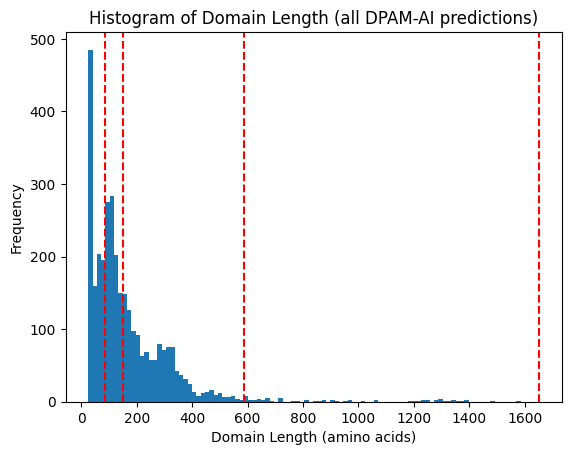

In [6]:
# Plot histogram of domain_length
import matplotlib.pyplot as plt

plt.hist(df_dpam['domain_length'], bins=100)

# Draw vertical lines at bin boundaries
for i in range(len(twist_bin_protein)):
    if i > 0 and i < 5000:
        plt.axvline(x=twist_bin_protein[i], color='red', linestyle='--')

plt.xlabel('Domain Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Histogram of Domain Length (all DPAM-AI predictions)')
plt.show()


___
### Step 2 - Filter out transmembrane and extracellular domain using pre-computed deepTMHMM annotation

In [7]:
# Function to return the protein sequence of a .pdb file between resi_start and resi_end using Biopython
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import protein_letters_3to1
parser = PDBParser(QUIET=True)

def get_protein_sequence(struct, resi_start, resi_end, chain_id=None):
    # Assume 1st model
    model = struct[0]
    # Default to the first chain if chain_id is not specified
    chains = list(model.get_chains())
    if chain_id is None:
        chain = chains[0]
    else:
        chain = model[chain_id]

    residues_in_range = [res for res in chain if res.id[1] >= resi_start and res.id[1] <= resi_end]
    # Build the sequence from residues in range
    seq = ""
    for res in residues_in_range:
        if 'CA' in res and res.resname in protein_letters_3to1:
            seq += protein_letters_3to1[res.resname]
    return seq

row = df_dpam.iloc[0]
subset = row['subset']
protein = row['Protein']
pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
struct = parser.get_structure('protein', pdb_file)
get_protein_sequence(struct, 1, 100)


'MPALGWAVAAILMLQTAMAEPSPGTLPRKAGVFSDLSNQELKAVHSFLWSKKELRLQPSSTTTMAKNTVFLIEMLLPKKYHVLRFLDKGERHPVREARAV'

In [8]:
# ------ Helper functions to compute intracellular percentage ------

from Bio import pairwise2

# Compute intracellular_percentage using deepTMHMM annotation
deepTMHMM_dir = "/work/upthomae/Meng/hp_list_DeepTMHMM/out/"

# Function to get the deepTMHMM topology of a protein sequence and percentage identity from alignment
def get_deepTMHMM_topology(protein_sequence, uniprot_id, deepTMHMM_dir):
    # Construct the path to the .3line file
    three_line_file = os.path.join(deepTMHMM_dir, uniprot_id, "predicted_topologies.3line")

    # Load the .3line file: 1st line is header, 2nd is full sequence, 3rd is topology
    with open(three_line_file, "r") as f:
        lines = [l.strip() for l in f.readlines()]
    full_seq_3line = lines[1]
    topology_3line = lines[2]

    # Find the best local alignment of protein_sequence within full_seq_3line

    aln = pairwise2.align.localms(
        full_seq_3line, protein_sequence,
        2,   # match
        -1,  # mismatch
        -1,  # gap open
        -0.1,# gap extend
        one_alignment_only=True
    )

    # Extract the aligned region indices in full_seq_3line and compute percent identity
    if aln:
        a = aln[0]
        aln_start = a.start
        aln_end = a.end    # exclusive

        # Extract part of full_seq_3line that matches protein_sequence
        matched_full_seq = full_seq_3line[aln_start:aln_end]
        matched_topology = topology_3line[aln_start:aln_end]

        # Calculate percent identity on the aligned region
        aligned_query = a.seqB[a.start:a.end]
        identities = sum(aa1 == aa2 for aa1, aa2 in zip(matched_full_seq, aligned_query))
        percent_identity = 100.0 * identities / len(matched_full_seq) if matched_full_seq else 0.0
    else:
        matched_full_seq = ""
        matched_topology = ""
        percent_identity = 0.0

    return matched_full_seq, matched_topology, percent_identity


# #

# Function to compute the percentage of intracellular residues in matched_topology (not O or M)
def compute_intracellular_percentage(topology):
    if not topology:
        return 0.0
    non_o_m = sum(1 for t in topology if t not in ('O', 'M'))
    return 100.0 * non_o_m / len(topology)

/home/ymeng/miniconda3/envs/MaSIF/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [9]:
# Workflow to compute intracellular percentage from a row of df_dpam
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

def calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=False):
    """
    Given a row from df_dpam, return intracellular_percentage for the domain.
    Optionally print debugging messages if debug=True.
    Handles domains with potential gaps (comma-separated ranges).
    Tries to catch edge case errors (such as file not found, alignment failure)
    by imputing 1 for intracellular_percentage.
    """
    try:
        subset = row['subset']
        protein = row['Protein']
        range_str = row['Range']
        
        # Handle gap in range_str by splitting range_str into ranges
        ranges = range_str.split(',')

        all_protein_seqs = []
        all_matched_full_seqs = []
        all_matched_topologies = []
        percent_identities = []

        for segment in ranges:
            seg = segment.strip()
            resi_start, resi_end = int(seg.split('-')[0]), int(seg.split('-')[1])
            pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
            struct = parser.get_structure('protein', pdb_file)
            protein_sequence = get_protein_sequence(struct, resi_start, resi_end)
            matched_full_seq, matched_topology, percent_identity = get_deepTMHMM_topology(
                protein_sequence, protein, deepTMHMM_dir
            )
            all_protein_seqs.append(protein_sequence)
            all_matched_full_seqs.append(matched_full_seq)
            all_matched_topologies.append(matched_topology)
            percent_identities.append(percent_identity)
        
        # Calculate total percent identity for the overall domain by weighted averaging by length
        total_length = sum(len(seq) for seq in all_matched_full_seqs if seq)
        if total_length > 0:
            weighted_identity = sum(
                percent_identity * len(seq) for percent_identity, seq in zip(percent_identities, all_matched_full_seqs) if seq
            ) / total_length
        else:
            weighted_identity = 0.0

        if weighted_identity < 0.8:
            if debug:
                print(f"Warning: Weighted percent identity {weighted_identity}% is less than 80%, imputing intracellular percentage to 1")
            intracellular_percentage = 1
        else:
            # Concatenate matched_topology for all segments and compute intracellular percentage
            topology_concat = "".join(all_matched_topologies)
            intracellular_percentage = compute_intracellular_percentage(topology_concat)

        if debug:
            print("pdb_file:", pdb_file)
            print("protein_sequences:", all_protein_seqs)
            print("matched_full_seqs:", all_matched_full_seqs)
            print("matched_topologies:", all_matched_topologies)
            print("Percent identities:", percent_identities)
            print("Weighted percent identity: {:.2f}%".format(weighted_identity))
            print("Intracellular percentage: {:.2f}%".format(intracellular_percentage))

        return intracellular_percentage

    except Exception as e:
        print("Exception occurred in calc_intracellular_percentage_from_row:", e)
        import traceback
        traceback.print_exc()
        print("Imputing intracellular percentage to 1 due to error.")
        return 1

# Test it on a row with gap (Range contains comma)
row = df_dpam[df_dpam['Range'].str.contains(',')].iloc[0]
print(row)
calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=True)

Protein                   P49915
Domain                       nD2
Range            216-485,491-693
ECOD_num                 2832076
ECOD_key                 e7mo6B3
T-group                 2005.1.1
DPAM_prob                  0.992
HH_prob                      1.0
DALI_zscore                 19.6
Hit_cov                    0.933
Tgroup_cov                  2.21
Judge                good_domain
Hcount                        15
Scount                        13
subset                 subset_88
domain_length                473
bin                            2
Name: 31, dtype: object
pdb_file: /scratch/ymeng/DPAM/pacini_results/step2/subset_88/P49915.pdb
protein_sequences: ['TFTVQNRELECIREIKERVGTSKVLVLLSGGVDSTVCTALLNRALNQEQVIAVHIDNGFMRKRESQSVEEALKKLGIQVKVINAAHSFYNGTTTLPISDEDRTPRKRISKTLNMTTSPEEKRKIIGDTFVKIANEVIGEMNLKPEEVFLAQGTLRPDLIESASLVASGKAELIKTHHNDTELIRKLREEGKVIEPLKDFHKDEVRILGRELGLPEELVSRHPFPGPGLAIRVICAEEPYICKDFPETNNILKIVADFSASVKKPHTLLQR', 'TEEDQEKLMQITSLHSLNAFLLPIKTVGVQGDCRSYSYVCGISSKDEP

100.0

### Save to .csv file with deepTMHMM metrics

In [ ]:
# # Apply calc_intracellular_percentage_from_row to df_dpam
# df_dpam['intracellular_percentage'] = df_dpam.apply(lambda row: calc_intracellular_percentage_from_row(row, root_dir, deepTMHMM_dir, debug=False), axis=1)
# df_dpam.head()

In [ ]:
# # write df_dpam to csv
# df_dpam.to_csv("./output/pacini_domains_deepTMHMM.csv", index=False)

In [10]:
df_dpam = pd.read_csv("./output/pacini_domains_deepTMHMM.csv")

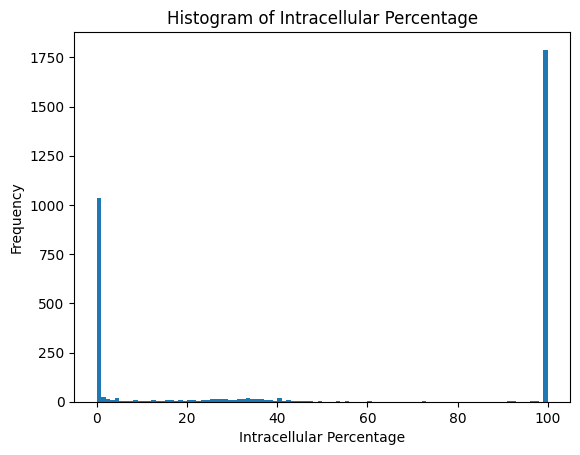

In [11]:
import matplotlib.pyplot as plt
# plot histogram of intracellular_percentage
plt.hist(df_dpam['intracellular_percentage'], bins=100)
plt.xlabel('Intracellular Percentage')
plt.ylabel('Frequency')
plt.title('Histogram of Intracellular Percentage')
plt.show()


In [12]:
# Filter out poor quality domains
df_dpam_filtered = df_dpam.copy()
n_row_total = df_dpam_filtered.shape[0]
print(f"Before filtering: {n_row_total}")

# Remove rows where DPAM_prob is na
df_dpam_filtered = df_dpam_filtered[df_dpam_filtered['DPAM_prob'] != "na"]

n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where DPAM_prob is na")

# Convert numeric columns to float
df_dpam_filtered['DPAM_prob'] = df_dpam_filtered['DPAM_prob'].astype(float)
df_dpam_filtered['intracellular_percentage'] = df_dpam_filtered['intracellular_percentage'].astype(float)

# 1. Remove entries where judge is simple_topology AND DPAM_prob < 0.98
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['Judge'] != 'simple_topology') | 
    (df_dpam_filtered['DPAM_prob'] >= 0.98)
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where Judge is simple_topology and DPAM_prob < 0.98")

# 2. Remove entries where low_confidence judge
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['Judge'] != 'low_confidence')
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where Judge is low_confidence")

# 3. Remove non-intracellular domains (intracellular_percentage < 50)
df_dpam_filtered = df_dpam_filtered[
    (df_dpam_filtered['intracellular_percentage'] >= 50)
]
n_row = df_dpam_filtered.shape[0]
print(f"Removed {n_row_total - n_row} rows where intracellular_percentage < 50")

print(f"Before filtering: {df_dpam.shape}")
print(f"After filtering: {df_dpam_filtered.shape}")

Before filtering: 3285
Removed 34 rows where DPAM_prob is na
Removed 341 rows where Judge is simple_topology and DPAM_prob < 0.98
Removed 373 rows where Judge is low_confidence
Removed 1713 rows where intracellular_percentage < 50
Before filtering: (3285, 18)
After filtering: (1572, 18)


In [13]:
# Determine the bin for each domain
df_dpam_filtered['bin'] = pd.cut(df_dpam_filtered['domain_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of domain_length in each bin
df_summary = df_dpam_filtered.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'domain_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()

/tmp/ipykernel_1485290/2364061194.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam_filtered.groupby('bin').agg({'Domain': 'count', 'domain_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,331,19626,58878,0,300.0
1,1,496,58063,174189,300,500.0
2,2,708,193345,580035,500,1800.0
3,3,37,29171,87513,1800,5000.0
4,4,0,0,0,5000,inf


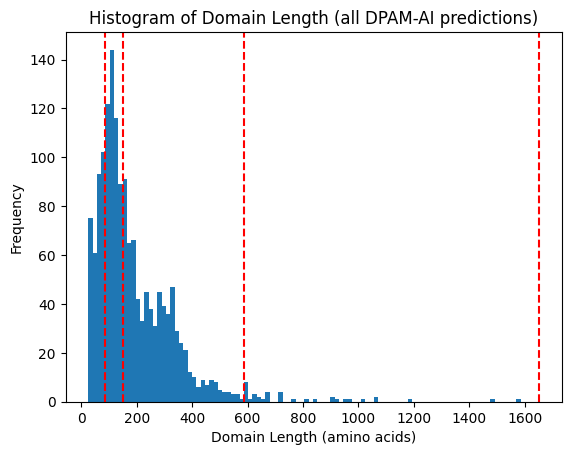

In [14]:
# Plot histogram of domain_length
import matplotlib.pyplot as plt

plt.hist(df_dpam_filtered['domain_length'], bins=100)

# Draw vertical lines at bin boundaries
for i in range(len(twist_bin_protein)):
    if i > 0 and i < 5000:
        plt.axvline(x=twist_bin_protein[i], color='red', linestyle='--')

plt.xlabel('Domain Length (amino acids)')
plt.ylabel('Frequency')
plt.title('Histogram of Domain Length (all DPAM-AI predictions)')
plt.show()


_______
### Step 3 - Handle gaps in sequence
df_dpam_filtered is subset to those that contain gaps, and handled accordingly, before merging back with the remaining rows.

In [15]:
# -------- Functions to deal with gaps in domain ranges --------

# Function to return the number of gaps (count commas)
def num_gaps(range_str):
    return range_str.count(',')

#num_gaps('1-10,15-20,25-30') 


# Function to compute the length of the domain (with gaps)
def domain_length_gap(range_str):
    """
    Calculate the total length of a domain by summing the lengths of all its fragments.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"
        
    Returns:
        int: The total length of the domain
    """
    # Split the range string into individual ranges
    ranges = [tuple(map(int, frag.split('-'))) for frag in range_str.split(',')]
    
    # Calculate the total length of the domain
    total_length = sum(end - start + 1 for start, end in ranges)

    return total_length

# print(domain_length_gap('1-10,16-20,26-30'))
# Returns 20

# Function to compute the total length of the domain (continuous)
def domain_length_continuous(range_str):
    """
    Calculate the total length of a domain from the residue with lowest index to the residue with highest index
    across all fragments in the range string.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"

    Returns:
        int: The total (continuous) length of the domain
    """
    # Split the range string into fragments
    fragments = range_str.split(',')
    starts = []
    ends = []
    for frag in fragments:
        frag = frag.strip()
        if '-' in frag:
            start_str, end_str = frag.split('-')
            starts.append(int(start_str))
            ends.append(int(end_str))
        else:
            # In case there is a single residue, e.g., "42"
            starts.append(int(frag))
            ends.append(int(frag))
    min_start = min(starts)
    max_end = max(ends)
    return max_end - min_start + 1

print(domain_length_continuous('1-10,16-20,26-30'))
# Returns 30

30


In [16]:
# Apply gap_length and num_gaps to df_domains
df_dpam_filtered['num_gaps'] = df_dpam_filtered['Range'].apply(num_gaps)

df_dpam_filtered.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415,65,0,100.0,0
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415,60,0,100.0,0
5,P05771,nD3,156-290,179750,e3pfqA2,11.2.1,0.998,1.0,26.1,0.971,0.957,good_domain,3,7,subset_415,135,1,100.0,0
6,P05771,nD4,326-665,1397996,e4ra5A1,206.1.1,0.999,1.0,46.6,0.97,1.13,good_domain,11,8,subset_415,340,2,100.0,0
8,Q9GZQ8,nD1,1-120,2628875,e7brnA1,221.1.1,0.997,1.0,18.4,0.872,1.277,good_domain,4,6,subset_98,120,1,100.0,0


In [ ]:
# # subset to only those with gaps
# df_dpam_gap = df_dpam_filtered[df_dpam_filtered['num_gaps'] > 0]
# df_dpam_gap.head()

In [17]:
# Parameters to handle gaps
min_gap_size = 20
median_linker_length_ref_csv = "./notebooks/median_linker_length.csv"

In [19]:
# # --------- Helper functions to graft GS linker to bridge gaps ---------

# Function to return the CA coordinate of a residue in a struct
def get_CA_coord(struct, resi, chain=None):
    """
    Get the CA coordinate of a residue in a structure.
    
    Args:
        struct: Bio.PDB.Structure.Structure object
        resi: Residue number (int)
        chain: Bio.PDB.Chain object (optional, assume the first chain if not specified)

    Returns:
        tuple: (x, y, z) coordinates of the CA atom
    """
    if chain is None:
        chain = list(struct.get_chains())[0]
    for residue in chain:
        if residue.id[1] == resi:
            return residue['CA'].get_coord()
    return None



In [20]:
# ========== REFACTORED LINKER GAP HANDLING ==========
# Clean implementation that handles out-of-range distances gracefully

class UnlinkableGapError(Exception):
    """
    Exception raised when a gap between fragments cannot be bridged by a GS linker
    because the CA-CA distance exceeds the maximum available in the reference table.
    """
    def __init__(self, gap_indices, distances, max_linkable_dist):
        """
        Args:
            gap_indices: List of gap indices (0-based) where gaps cannot be linked
            distances: List of CA distances for each unlinkable gap
            max_linkable_dist: Maximum distance that can be linked according to reference table
        """
        self.gap_indices = gap_indices
        self.distances = distances
        self.max_linkable_dist = max_linkable_dist
        message = (f"Cannot link gaps at indices {gap_indices} with distances {[f'{d:.2f}' for d in distances]} Å. "
                   f"Maximum linkable distance is {max_linkable_dist:.2f} Å.")
        super().__init__(message)

In [21]:
def get_GS_linker(dist, df_median_linker_length):
    """
    Get the GS linker sequence based on the distance between CA atoms of two residues.
    
    This is a refactored version that handles out-of-range distances gracefully.
    
    Args:
        dist: Euclidean distance (Å) between CA atoms
        df_median_linker_length: DataFrame with columns 'calpha_dist' and 'seq_dist'
    
    Returns:
        tuple: (linker_seq, success)
            - linker_seq: Linker sequence string if successful, None otherwise
            - success: True if a linker was found, False if distance exceeds table maximum
    """
    # Get maximum linkable distance from the reference table
    max_calpha_dist = df_median_linker_length['calpha_dist'].max()
    
    # If distance exceeds maximum, cannot provide a linker
    if dist > max_calpha_dist:
        return None, False
    
    # Find the first row where calpha_dist is greater than dist
    filtered_df = df_median_linker_length[df_median_linker_length['calpha_dist'] > dist]
    
    # This should not be empty given the check above, but be defensive
    if filtered_df.empty:
        return None, False
    
    row = filtered_df.iloc[0]
    linker_length = int(row['seq_dist'])
    
    # Generate linker sequence based on linker_length
    linker_seq = ""
    if linker_length == 2:
        linker_seq = "GG"
    elif linker_length == 3:
        linker_seq = "GSG"
    elif linker_length == 4:
        linker_seq = "GSSG"
    elif linker_length >= 5:
        # For linker_length >= 5, repeat GGSS so that first and last residues are G
        core_repeat = "GGSS"
        linker_seq = "G"
        residues = 1
        while residues + 4 <= linker_length:
            linker_seq += core_repeat
            residues += 4
        # Fill up to needed length with Gs, but last residue must be G
        while residues < linker_length - 1:
            linker_seq += "G"
            residues += 1
        linker_seq += "G"
        # Replace "GGG" with "GSG"
        linker_seq = linker_seq.replace("GGG", "GSG")
    
    return linker_seq, True

In [22]:
def analyze_gaps(range_str, subset, protein, min_gap_size, df_median_linker_length):
    """
    Analyze all gaps between fragments in a domain range string.
    
    Determines for each gap whether it can be bridged by a GS linker based on:
    - Gap length (sequence distance)
    - CA-CA distance (3D spatial distance)
    - min_gap_size parameter
    - Maximum linkable distance in reference table
    
    Args:
        range_str: Comma-separated list of residue ranges (e.g., "6-40,61-410,791-830")
        subset: Subset folder identifier to find the PDB file
        protein: UniProt protein accession
        min_gap_size: Minimum gap size to consider for GS linker grafting
        df_median_linker_length: DataFrame with linker reference data
    
    Returns:
        list: List of dictionaries, one per gap, with keys:
            - gap_index: Index of the gap (0-based, between fragments[i] and fragments[i+1])
            - gap_length: Sequence distance (number of residues)
            - ca_distance: 3D Euclidean distance between CA atoms (Å)
            - can_link: Boolean indicating if gap can be linked with GS linker
            - linker_seq: Linker sequence if can_link=True, None otherwise
            - linker_type: "GS" or "uniprot"
    """
    from Bio.PDB import PDBParser
    
    fragments = [f.strip() for f in range_str.split(',')]
    
    # If only one fragment, no gaps to analyze
    if len(fragments) <= 1:
        return []
    
    # Load structure
    pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure('protein', pdb_file)
    
    gap_analyses = []
    max_calpha_dist = df_median_linker_length['calpha_dist'].max()
    
    for i in range(len(fragments) - 1):
        frag_i = fragments[i]
        frag_next = fragments[i + 1]
        
        frag_i_start, frag_i_end = map(int, frag_i.split('-'))
        frag_next_start, frag_next_end = map(int, frag_next.split('-'))
        
        # Calculate gap length (sequence distance)
        gap_length = frag_next_start - frag_i_end
        
        # Get CA coordinates and calculate 3D distance
        frag_i_end_CA_coord = get_CA_coord(struct, frag_i_end)
        frag_next_start_CA_coord = get_CA_coord(struct, frag_next_start)
        
        if frag_i_end_CA_coord is None or frag_next_start_CA_coord is None:
            # If we can't get coordinates, cannot link
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': None,
                'can_link': False,
                'linker_seq': None,
                'linker_type': None
            })
            continue
        
        ca_distance = np.linalg.norm(np.array(frag_i_end_CA_coord) - np.array(frag_next_start_CA_coord))
        
        # Determine if gap should use uniprot sequence (min_gap_size check)
        if (min_gap_size is not None) and (gap_length < min_gap_size):
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': ca_distance,
                'can_link': False,  # Will use uniprot instead
                'linker_seq': None,
                'linker_type': 'uniprot'
            })
            continue
        
        # Try to get GS linker
        linker_seq, success = get_GS_linker(ca_distance, df_median_linker_length)
        
        if not success:
            # Distance exceeds maximum - gap cannot be linked
            gap_analyses.append({
                'gap_index': i,
                'gap_length': gap_length,
                'ca_distance': ca_distance,
                'can_link': False,
                'linker_seq': None,
                'linker_type': None  # This signals unlinkable gap
            })
            continue
        
        # Check if GS linker length is reasonable compared to gap length
        linker_type = "GS"
        if gap_length > 0 and len(linker_seq) / gap_length > 0.5:
            # GS linker is too long relative to gap - use uniprot sequence instead
            linker_type = "uniprot"
            linker_seq = None  # Will be filled from structure
        
        gap_analyses.append({
            'gap_index': i,
            'gap_length': gap_length,
            'ca_distance': ca_distance,
            'can_link': (linker_type == "GS"),
            'linker_seq': linker_seq,
            'linker_type': linker_type
        })
    
    return gap_analyses

In [23]:
def split_domain_at_gaps(row, unlinkable_gap_indices):
    """
    Split a domain row into multiple domain rows at specified gap indices.
    
    Args:
        row: Pandas Series representing a domain row
        unlinkable_gap_indices: List of gap indices (0-based) where splitting should occur
    
    Returns:
        pd.DataFrame: DataFrame with one row per resulting domain fragment
    """
    if not unlinkable_gap_indices:
        return pd.DataFrame([row])
    
    range_str = row['Range']
    fragments = [f.strip() for f in range_str.split(',')]
    
    # Sort gap indices
    unlinkable_gap_indices = sorted(set(unlinkable_gap_indices))
    
    # Create split points: each gap index means split after fragment at that index
    split_points = [idx + 1 for idx in unlinkable_gap_indices]
    
    # Split fragments into groups
    domain_groups = []
    start_idx = 0
    for split_idx in split_points:
        if split_idx <= len(fragments):
            domain_groups.append(fragments[start_idx:split_idx])
            start_idx = split_idx
    # Add remaining fragments
    if start_idx < len(fragments):
        domain_groups.append(fragments[start_idx:])
    
    # Create a row for each domain group
    rows = []
    for idx, frag_group in enumerate(domain_groups, start=1):
        row_new = row.copy()
        row_new['Domain'] = f"{row['Domain']}.{idx}"
        row_new['Range'] = ",".join(frag_group)
        row_new['num_gaps'] = num_gaps(row_new['Range'])
        rows.append(row_new)
    
    return pd.DataFrame(rows).reset_index(drop=True)

In [24]:
df_median_linker_length = pd.read_csv(median_linker_length_ref_csv)

def graft_GS_linkers(range_str, subset, protein, min_gap_size, df_median_linker_length):
    """
    Graft GS linkers to bridge gaps in a protein domain (refactored version).
    
    Uses analyze_gaps to determine linkability. Raises UnlinkableGapError if any gap
    cannot be linked.
    
    Args:
        range_str: Comma-separated list of residue ranges
        subset: Subset folder identifier
        protein: UniProt protein accession
        min_gap_size: Minimum gap size for GS linker consideration
        df_median_linker_length: Linker reference DataFrame
    
    Returns:
        tuple: (linker_seqs, linker_types, full_seq)
            - linker_seqs: Comma-separated linker sequences
            - linker_types: Comma-separated linker types ("GS" or "uniprot")
            - full_seq: Full concatenated sequence
    
    Raises:
        UnlinkableGapError: If any gap cannot be linked (distance too large)
    """
    from Bio.PDB import PDBParser
    
    fragments = [f.strip() for f in range_str.split(',')]
    
    # Handle single fragment case
    if len(fragments) == 1:
        frag_start, frag_end = map(int, fragments[0].split('-'))
        pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
        parser = PDBParser(QUIET=True)
        struct = parser.get_structure('protein', pdb_file)
        full_seq = get_protein_sequence(struct, frag_start, frag_end)
        return None, None, full_seq
    
    # Analyze all gaps
    gap_analyses = analyze_gaps(range_str, subset, protein, min_gap_size, df_median_linker_length)
    
    # Check for unlinkable gaps (where ca_distance exceeds maximum)
    unlinkable_gaps = [
        (gap['gap_index'], gap['ca_distance'])
        for gap in gap_analyses
        if gap['ca_distance'] is not None and gap['linker_type'] is None
    ]
    
    if unlinkable_gaps:
        gap_indices, distances = zip(*unlinkable_gaps)
        max_linkable_dist = df_median_linker_length['calpha_dist'].max()
        raise UnlinkableGapError(list(gap_indices), list(distances), max_linkable_dist)
    
    # Load structure for sequence extraction
    pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure('protein', pdb_file)
    
    linker_seqs = []
    linker_types = []
    full_seqs = []
    
    for i, gap_info in enumerate(gap_analyses):
        # Add fragment sequence
        frag_i = fragments[i]
        frag_i_start, frag_i_end = map(int, frag_i.split('-'))
        full_seqs.append(get_protein_sequence(struct, frag_i_start, frag_i_end))
        
        # Handle linker
        linker_type = gap_info['linker_type']
        if linker_type == "GS":
            linker_seq = gap_info['linker_seq']
        elif linker_type == "uniprot":
            # Extract uniprot sequence for the gap
            frag_next = fragments[i + 1]
            frag_next_start = int(frag_next.split('-')[0])
            gap_resi_start = frag_i_end + 1
            gap_resi_end = frag_next_start - 1
            if gap_resi_start <= gap_resi_end:
                linker_seq = get_protein_sequence(struct, gap_resi_start, gap_resi_end)
            else:
                linker_seq = ""
        else:
            # Should not happen given the checks above
            linker_seq = ""
            linker_type = "uniprot"
        
        linker_seqs.append(linker_seq)
        linker_types.append(linker_type)
        full_seqs.append(linker_seq)
    
    # Add last fragment
    frag_last = fragments[-1]
    frag_last_start, frag_last_end = map(int, frag_last.split('-'))
    full_seqs.append(get_protein_sequence(struct, frag_last_start, frag_last_end))
    
    # Format return values
    linker_seqs_str = ",".join(linker_seqs)
    linker_types_str = ",".join(linker_types)
    full_seq = "".join(full_seqs)
    
    return linker_seqs_str, linker_types_str, full_seq

In [ ]:
def handle_gaps_and_linkers(row, min_gap_size):
    """
    Process a domain row: handle splitting and grafting linkers (refactored version).
    
    Pipeline:
    1. Check if there is any gap in the domain, if not, return the original row with None in 
        the linker_seqs, linker_types, linker_error columns, and return the sequence in full_seq
    2. Length-based splitting: If domain_length > 586, split by fragments
    3. Unlinkable gap detection: Try to graft linkers, detect gaps that cannot be linked
    4. Gap-based splitting: Split at all unlinkable gaps
    5. Final linker grafting: Process each resulting domain
    
    Args:
        row: Pandas Series representing a domain row
        min_gap_size: Minimum gap size parameter for GS linker consideration
    
    Returns:
        pd.DataFrame: DataFrame with processed domain rows (may be multiple if split) with
        the following new columns:
            - linker_seqs
            - linker_types
            - full_seq
            - linker_error
    """
    row = row.copy()
    subset = row['subset']
    protein = row['Protein']
    range_str = row['Range']
    fragments = [f.strip() for f in range_str.split(',')]

    # Step 1: Check if there is any gap in the domain (more than one fragment)
    if len(fragments) <= 1:
        # If no gap, return the original row with None in the new columns
        pdb_file = os.path.join(root_dir, "pacini_results", "step2", subset, f"{protein}.pdb")
        parser = PDBParser(QUIET=True)
        struct = parser.get_structure('protein', pdb_file)
        frag_start, frag_end = map(int, fragments[0].split('-'))
        full_seq = get_protein_sequence(struct, frag_start, frag_end)
        row['linker_seqs'] = None
        row['linker_types'] = None
        row['protein_seq'] = full_seq
        row['linker_error'] = None
        return pd.DataFrame([row])
    
    # Step 2: Length-based splitting
    domain_length = domain_length_gap(",".join(fragments))
    
    if domain_length > 586:
        # Split by fragments
        rows = []
        for idx, frag in enumerate(fragments, start=1):
            row_i = row.copy()
            row_i['Domain'] = f"{row['Domain']}.{idx}"
            row_i['Range'] = frag
            row_i['num_gaps'] = num_gaps(frag)
            rows.append(row_i)
        domains_to_process = pd.DataFrame(rows).reset_index(drop=True)
    else:
        domains_to_process = pd.DataFrame([row])
    
    # Step 3 & 4: Process each domain, handle unlinkable gaps by splitting
    final_rows = []
    
    for _, domain_row in domains_to_process.iterrows():
        this_range = domain_row['Range']
        
        try:
            # Try to graft linkers
            linker_seqs, linker_types, full_seq = graft_GS_linkers(
                this_range, subset, protein, min_gap_size, df_median_linker_length
            )
            
            # Success - add linker information to row
            domain_row = domain_row.copy()
            domain_row['linker_seqs'] = linker_seqs
            domain_row['linker_types'] = linker_types
            domain_row['protein_seq'] = full_seq
            domain_row['linker_error'] = None
            final_rows.append(domain_row)
            
        except UnlinkableGapError as e:
            # Step 3: Split domain at unlinkable gaps
            split_domains = split_domain_at_gaps(domain_row, e.gap_indices)
            
            # Recursively process each split domain
            for _, split_row in split_domains.iterrows():
                sub_results = handle_gaps_and_linkers(split_row, min_gap_size)
                final_rows.extend(sub_results.to_dict(orient='records'))
        
        except Exception as e:
            # Unexpected error - mark as failed but don't crash
            print(f"Unexpected error processing domain {domain_row.get('Domain', 'unknown')}: {e}")
            import traceback
            traceback.print_exc()
            domain_row = domain_row.copy()
            domain_row['linker_seqs'] = None
            domain_row['linker_types'] = None
            domain_row['protein_seq'] = None
            domain_row['linker_error'] = str(e)
            final_rows.append(domain_row)
    
    return pd.DataFrame(final_rows).reset_index(drop=True)

# Example usage
row = df_dpam_filtered.iloc[0] # Row with no gap
#row = df_dpam_filtered[df_dpam_filtered['num_gaps'] > 0].iloc[0] # Row with gap
handle_gaps_and_linkers(row, min_gap_size=min_gap_size)


,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,full_seq,linker_error
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,...,4,subset_415,65,0,100.0,0,None,None,VHEVKNHKFTARFFKQPTFCSHCTDFIWGFGKQGFQCQVCCFVVHK...,None


In [30]:
# Apply handle_gaps_and_linkers to df_dpam_filtered

# Initialize empty DataFrame before loop
df_dpam_filtered_seq = pd.DataFrame()

for i, (idx, row) in enumerate(df_dpam_filtered.iterrows(), start=1):
    print(f"Processing row {i} of {len(df_dpam_filtered)} (df index {idx})")
    try:
        result = handle_gaps_and_linkers(row, min_gap_size=min_gap_size)
        df_dpam_filtered_seq = pd.concat([df_dpam_filtered_seq, result], ignore_index=True)
    except Exception as e:
        print(f"Error processing row {i} (df index {idx}): {e}")

df_dpam_filtered_seq.head()

Processing row 1 of 1572 (df index 3)
Processing row 2 of 1572 (df index 4)
Processing row 3 of 1572 (df index 5)
Processing row 4 of 1572 (df index 6)
Processing row 5 of 1572 (df index 8)
Processing row 6 of 1572 (df index 10)
Processing row 7 of 1572 (df index 11)
Processing row 8 of 1572 (df index 12)
Processing row 9 of 1572 (df index 13)
Processing row 10 of 1572 (df index 14)
Processing row 11 of 1572 (df index 15)
Processing row 12 of 1572 (df index 16)
Processing row 13 of 1572 (df index 17)
Processing row 14 of 1572 (df index 18)
Processing row 15 of 1572 (df index 19)
Processing row 16 of 1572 (df index 23)
Processing row 17 of 1572 (df index 24)
Processing row 18 of 1572 (df index 25)
Processing row 19 of 1572 (df index 26)
Processing row 20 of 1572 (df index 27)
Processing row 21 of 1572 (df index 28)
Processing row 22 of 1572 (df index 29)
Processing row 23 of 1572 (df index 30)
Processing row 24 of 1572 (df index 31)
Processing row 25 of 1572 (df index 36)
Processing row

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,full_seq,linker_error
0,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,...,4,subset_415,65,0,100.0,0,None,None,VHEVKNHKFTARFFKQPTFCSHCTDFIWGFGKQGFQCQVCCFVVHK...,None
1,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,...,2,subset_415,60,0,100.0,0,None,None,DDPRSKHKFKIHTYSSPTFCDHCGSLLYGLIHQGMKCDTCMMNVHK...,None
2,P05771,nD3,156-290,179750,e3pfqA2,11.2.1,0.998,1.0,26.1,0.971,...,7,subset_415,135,1,100.0,0,None,None,TERRGRIYIQAHIDRDVLIVLVRDAKNLVPMDPNGLSDPYVKLKLI...,None
3,P05771,nD4,326-665,1397996,e4ra5A1,206.1.1,0.999,1.0,46.6,0.97,...,8,subset_415,340,2,100.0,0,None,None,SKFDNNGNRDRMKLTDFNFLMVLGKGSFGKVMLSERKGTDELYAVK...,None
4,Q9GZQ8,nD1,1-120,2628875,e7brnA1,221.1.1,0.997,1.0,18.4,0.872,...,6,subset_98,120,1,100.0,0,None,None,MPSEKTFKQRRTFEQRVEDVRLIREQHPTKIPVIIERYKGEKQLPV...,None


In [ ]:
# Check if there is any row with linker_error
df_dpam_filtered_seq[df_dpam_filtered_seq['linker_error'].notna()]

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,Scount,subset,domain_length,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,full_seq,linker_error


In [ ]:
# Add 'seq_length' column because it is not always the same as domain_length
df_dpam_filtered_seq['seq_length'] = df_dpam_filtered_seq['protein_seq'].str.len()
df_dpam_filtered_seq.iloc[0]


Protein                                                                P05771
Domain                                                                    nD1
Range                                                                   31-95
ECOD_num                                                               167536
ECOD_key                                                              e2ennA1
T-group                                                               376.1.2
DPAM_prob                                                               0.997
HH_prob                                                                 0.878
DALI_zscore                                                               9.2
Hit_cov                                                                 0.829
Tgroup_cov                                                              1.048
Judge                                                             good_domain
Hcount                                                          

In [34]:
# Write to csv
df_dpam_filtered_seq.to_csv(os.path.join(root_dir, "output", "pacini_domains_library_260122.csv"), index=False)

___
### Step 4 - Deduplicate protein sequences by CD-HIT

In [21]:
import pandas as pd
# Reload filtered domain dataframe
df_dpam_filtered_seq = pd.read_csv(os.path.join(root_dir, "output", "pacini_domains_library_260122.csv"))

In [22]:
import subprocess
import os

# Set CD-HIT parameters
cdhit_exe = "cd-hit"
identity = "0.90"   # Cluster sequences with >= 90% identity together
word_length = "5"   # Word length for clustering

# Add unique uid to each row
df_dpam_filtered_seq['uid'] = np.arange(len(df_dpam_filtered_seq))

# Write all protein sequences to a FASTA file
fasta_path = os.path.join(root_dir, "output", "pacini_domains_library_260122.fasta")
with open(fasta_path, "w") as fasta_out:
    for i, row in df_dpam_filtered_seq.iterrows():
        header = f">{row['uid']}"
        seq = row['protein_seq']
        fasta_out.write(header + "\n" + seq + "\n")

# Run CD-HIT to deduplicate sequences
cdhit_output = os.path.join(root_dir, "output", "pacini_domains_library_260122_cdhit.fasta")
cdhit_clstr = cdhit_output + ".clstr"

cmd = [
    cdhit_exe,
    "-i", fasta_path,
    "-o", cdhit_output,
    "-c", identity,
    "-n", word_length,
    "-d", "0"  # full defline in output
]

# Execute CD-HIT
try:
    print("Running CD-HIT for protein deduplication...")
    subprocess.run(cmd, check=True)
    print(f"CD-HIT finished. Output written to {cdhit_output}")
except Exception as e:
    print(f"Error running CD-HIT: {e}")



Running CD-HIT for protein deduplication...
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /scratch/ymeng/DPAM/output/pacini_domains_library_260122.fasta
         -o
         /scratch/ymeng/DPAM/output/pacini_domains_library_260122_cdhit.fasta
         -c 0.90 -n 5 -d 0

Started: Thu Jan 22 10:55:43 2026
                            Output                              
----------------------------------------------------------------
total seq: 1649
longest and shortest : 1015 and 25
Total letters: 302933
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 82M

Table limit with the given memory limit:
Max number of representatives: 2045121
Max number of word counting entries: 89733557

comparing sequences from          0  to       1649
.
     1649  finished       1615  clusters

Approximated maximum memory consu

In [23]:
# Read CD-HIT output and add cluster_id to df_dpam_filtered_seq

# Prepare mapping from sequence header to cluster id
seq_to_cluster = {}

current_cluster_id = None

with open(cdhit_clstr, 'r') as f:
    for line in f:
        if line.startswith('>'):
            # New cluster, update the cluster id
            cluster_num = line.strip().split()[1]
            # e.g., ">Cluster 0" -> cluster_num = "0"
            current_cluster_id = int(cluster_num)
        else:
            # Sequence line; extract fasta header within '>'
            parts = line.strip().split()
            for part in parts:
                if part.startswith(">"):
                    # Remove '>' and trailing '...'
                    header = part[1:]
                    if header.endswith("..."):
                        header = header[:-3]
                    seq_to_cluster[header] = current_cluster_id
                    break

# Assign cluster_id for each row in df_dpam_filtered_seq
def get_cdhit_header(row):
    # Should match header constructed in FASTA:
    return f"{row['uid']}"

df_dpam_filtered_seq['cluster_id'] = df_dpam_filtered_seq.apply(
    lambda row: seq_to_cluster.get(get_cdhit_header(row), None), axis=1
)

# Find rows where cluster_id is None
df_dpam_filtered_seq[df_dpam_filtered_seq['cluster_id'].isna()]

# assign unique negative integers to these rows where cd-hit failed to cluster
df_dpam_filtered_seq.loc[df_dpam_filtered_seq['cluster_id'].isna(), 'cluster_id'] = -1 * np.arange(1, len(df_dpam_filtered_seq[df_dpam_filtered_seq['cluster_id'].isna()]) + 1)

# Make sure cluster_id is an integer
df_dpam_filtered_seq['cluster_id'] = df_dpam_filtered_seq['cluster_id'].astype(int)

df_dpam_filtered_seq.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,...,bin,intracellular_percentage,num_gaps,linker_seqs,linker_types,protein_seq,linker_error,seq_length,uid,cluster_id
0,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,...,0,100.0,0,NaN,NaN,VHEVKNHKFTARFFKQPTFCSHCTDFIWGFGKQGFQCQVCCFVVHK...,NaN,65,0,1401
1,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.000,...,0,100.0,0,NaN,NaN,DDPRSKHKFKIHTYSSPTFCDHCGSLLYGLIHQGMKCDTCMMNVHK...,NaN,60,1,1428
2,P05771,nD3,156-290,179750,e3pfqA2,11.2.1,0.998,1.000,26.1,0.971,...,1,100.0,0,NaN,NaN,TERRGRIYIQAHIDRDVLIVLVRDAKNLVPMDPNGLSDPYVKLKLI...,NaN,135,2,843
3,P05771,nD4,326-665,1397996,e4ra5A1,206.1.1,0.999,1.000,46.6,0.970,...,2,100.0,0,NaN,NaN,SKFDNNGNRDRMKLTDFNFLMVLGKGSFGKVMLSERKGTDELYAVK...,NaN,340,3,180
4,Q9GZQ8,nD1,1-120,2628875,e7brnA1,221.1.1,0.997,1.000,18.4,0.872,...,1,100.0,0,NaN,NaN,MPSEKTFKQRRTFEQRVEDVRLIREQHPTKIPVIIERYKGEKQLPV...,NaN,120,4,952


In [25]:
# Deduplicate df_dpam_filtered_seq by cluster_id (retaining the row with the highest DPAM_prob)
df_dpam_filtered_seq_dedup = df_dpam_filtered_seq.sort_values(by='DPAM_prob', ascending=False).drop_duplicates(subset='cluster_id')

# Create a df to store the rows that are dropped by deduplication
df_dpam_filtered_seq_dropped = df_dpam_filtered_seq[~df_dpam_filtered_seq['uid'].isin(df_dpam_filtered_seq_dedup['uid'])]

print(f"Deduplicated library: {df_dpam_filtered_seq_dedup.shape}")
print(f"Dropped domains: {df_dpam_filtered_seq_dropped.shape}")

Deduplicated library: (1619, 26)
Dropped domains: (34, 26)


In [31]:
# Inspect the dropped clusters
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

row = df_dpam_filtered_seq_dropped.iloc[3]
cluster_id = row['cluster_id']
df_cluster = df_dpam_filtered_seq[df_dpam_filtered_seq['cluster_id'] == cluster_id]

# Collect all protein sequences for alignment
seqs = df_cluster['protein_seq'].tolist()
names = df_cluster['Protein'].tolist()

# Use the first sequence as the reference
ref_seq = seqs[0]
ref_name = names[0]
# Print all alignments to the reference
for name, seq in zip(names, seqs):
    print(f">{name}")
    # Do alignment to ref_seq unless it's the reference
    if seq == ref_seq:
        print(seq)
    else:
        # Global alignment, simple scoring for demonstration
        # (Match +1, mismatch -1, open -0.5, extend -0.1)
        alns = pairwise2.align.globalms(ref_seq, seq, 1, -1, -0.5, -0.1)
        best_aln = alns[0]
        # Print both sequences aligned (reference/top, this protein/bottom)
        print(format_alignment(*best_aln))


>Q9BT81
SESRIRRPMNAFMVWAKDERKRLAVQNPDLHNAELSKMLGKSWKALTLSQKRPYVDEAERLRLQHMQDYPNYKYRPRRKK
>Q9H6I2
SESRIRRPMNAFMVWAKDERKRLAVQ-NPDLHNAELSKMLGKSWKALTLSQ--KRPY-VDE-AERLRL-QHMQDY-PNYKYRPRRKK
  |||||||||||||||||||||| | ||||||||||||||||||||||    |||  | | |||||  |||||  ||||||||   
--SRIRRPMNAFMVWAKDERKRLA-QQNPDLHNAELSKMLGKSWKALTL--AEKRP-FV-EEAERLR-VQHMQD-HPNYKYRPR---
  Score=60.5



In [32]:
# Write df_dpam_filtered_seq_dedup and df_dpam_filtered_seq_dropped to csv
df_dpam_filtered_seq_dedup.to_csv(os.path.join(root_dir, "output", "pacini_domains_library_260122_dedup.csv"), index=False)
df_dpam_filtered_seq_dropped.to_csv(os.path.join(root_dir, "output", "pacini_domains_library_260122_dropped.csv"), index=False)

____
### Final inspection of deduplicated library

In [33]:
# Determine the bin for each domain
df_dpam_filtered_seq_dedup['bin'] = pd.cut(df_dpam_filtered_seq_dedup['seq_length'], bins=twist_bin_protein, labels=range(len(twist_bin_protein)-1))

# Summarize the number of domains in each bin, and the sum of seq_length in each bin
df_summary = df_dpam_filtered_seq_dedup.groupby('bin').agg({'Domain': 'count', 'seq_length': 'sum'}).reset_index()
# rename the columns
df_summary.rename(columns={'Domain': 'n_domains', 'seq_length': 'sum_protein_length'}, inplace=True)
df_summary['sum_DNA_length'] = df_summary['sum_protein_length'] * 3
df_summary['min_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x])
df_summary['max_DNA'] = df_summary['bin'].apply(lambda x: twist_bin_DNA[x+1])
df_summary.head()

/tmp/ipykernel_1655869/1574085815.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_summary = df_dpam_filtered_seq_dedup.groupby('bin').agg({'Domain': 'count', 'seq_length': 'sum'}).reset_index()


,bin,n_domains,sum_protein_length,sum_DNA_length,min_DNA,max_DNA
0,0,368,21075,63225,0,300.0
1,1,490,57191,171573,300,500.0
2,2,742,205126,615378,500,1800.0
3,3,19,13035,39105,1800,5000.0
4,4,0,0,0,5000,inf


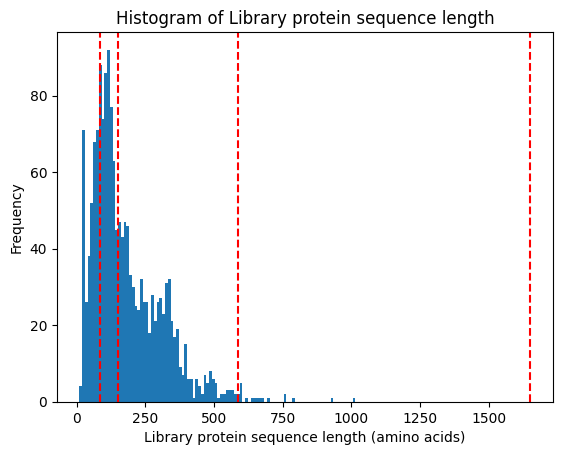

In [35]:
# Plot histogram of domain_length
import matplotlib.pyplot as plt

plt.hist(df_dpam_filtered_seq_dedup['seq_length'], bins=100)

# Draw vertical lines at bin boundaries
for i in range(len(twist_bin_protein)):
    if i > 0 and i < 5000:
        plt.axvline(x=twist_bin_protein[i], color='red', linestyle='--')

plt.xlabel('Library protein sequence length (amino acids)')
plt.ylabel('Frequency')
plt.title('Histogram of Library protein sequence length')
plt.show()


### Visualization of domains

In [39]:
import py3Dmol

data_dir = 'pacini_results'

# Function to visualize protein domains
def visualize_protein_domains(df_protein, data_dir, Domain=None):
    """
    Visualizes protein domains from a DataFrame row subset using py3Dmol.

    Args:
        df_protein (pd.DataFrame): Subset of domains DataFrame for a specific protein.
                                  Must have columns 'Domain', 'Range', 'Judge', and 'Protein'.
        data_dir (str): Path to the directory containing the pdb files.
        Domain (str, optional): Highlight this domain in red; others are colored with low-saturation colors.

    Returns:
        py3Dmol.view: The rendered 3Dmol.js view object.
    """
    # Distinct, saturated colors for multiple domains
    domain_colors = [
        'red', 'green', 'blue', 'orange', 'magenta', 'cyan', 'yellow', 'purple', 'brown', 'lime'
    ]
    # Low-saturation/pastel colors for background domains
    pale_colors = [
        '#FFB6B6',  # pale pink
        '#C6E2FF',  # pale blue
        '#B4EEB4',  # pale green
        '#FDFD96',  # pale yellow
        '#FFE4E1',  # misty rose
        '#E6E6FA',  # lavender
        '#FFFACD',  # lemon chiffon
        '#E0FFFF',  # light cyan
        '#F5E6FF',  # pale purple
        '#FFF0F5',  # lavender blush
    ]
    # Color to highlight the selected Domain
    highlight_color = 'blue'

    def parse_ranges(range_string):
        """Return list of (start, end) tuples (1-based inclusive) from a 'Range' string like '6-35,41-410'."""
        res = []
        for part in range_string.split(','):
            start, end = [int(x) for x in part.split('-')]
            res.append((start, end))
        return res

    # Determine model path from DataFrame
    protein_id = df_protein.iloc[0]['Protein']
    # Find the corresponding pdb file in data_dir/step2/subset_<n>/
    model_path = os.path.join(data_dir, f"step2/{df_protein.iloc[0]['subset']}/{protein_id}.pdb")

    view = py3Dmol.view(width=500, height=500)
    view.addModel(open(model_path).read(), 'pdb')

    # Set the default structure color to lightgrey
    view.setStyle({'cartoon': {'color': 'lightgrey'}})

    # Color scheme logic
    for idx, (domain_name, range_str, judge) in enumerate(zip(df_protein['Domain'], df_protein['Range'], df_protein['Judge'])):
        if Domain is None:
            # Legacy: color each domain unique color
            color = domain_colors[idx % len(domain_colors)]
        else:
            # New: color Domain as 'red', others as low-saturation
            if str(domain_name) == str(Domain):
                color = highlight_color
            else:
                # choose a pale color for "background" domains, cycling if more domains than colors
                color = pale_colors[idx % len(pale_colors)]
        domain_ranges = parse_ranges(range_str)
        for start, end in domain_ranges:
            selection = {'resi': list(range(start, end + 1))}
            view.setStyle(selection, {'cartoon': {'color': color}})

    view.zoomTo()
    return view

# example usage
df_protein = df_dpam_filtered_seq[df_dpam_filtered_seq['Protein'] == df_dpam_filtered_seq['Protein'].iloc[0]]
print(df_protein)
visualize_protein_domains(df_protein, data_dir, 'nD1')

  Protein Domain    Range ECOD_num ECOD_key  T-group  DPAM_prob HH_prob  \
0  P05771    nD1    31-95   167536  e2ennA1  376.1.2      0.997   0.878   
1  P05771    nD2   96-155  2581364  e6ra0A2  376.1.2      0.996   0.937   
2  P05771    nD3  156-290   179750  e3pfqA2   11.2.1      0.998     1.0   
3  P05771    nD4  326-665  1397996  e4ra5A1  206.1.1      0.999     1.0   

  DALI_zscore Hit_cov  ...      subset domain_length  bin  \
0         9.2   0.829  ...  subset_415            65    0   
1         9.1     1.0  ...  subset_415            60    0   
2        26.1   0.971  ...  subset_415           135    1   
3        46.6    0.97  ...  subset_415           340    2   

   intracellular_percentage num_gaps  linker_seqs linker_types  \
0                     100.0        0         None         None   
1                     100.0        0         None         None   
2                     100.0        0         None         None   
3                     100.0        0         None     

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [52]:
# Inpsect row by row
row_idx = 0
protein_ids = df_dpam_filtered_seq['Protein'].unique()

In [73]:
row_idx += 1
df_protein = df_dpam_filtered_seq[df_dpam_filtered_seq['Protein'] == protein_ids[row_idx]]
visualize_protein_domains(df_protein, data_dir)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# ----- Interactive scatter plot with py3Dmol view rendering on click -----
import plotly.express as px
import plotly.graph_objs as go
from IPython.display import display, clear_output
import ipywidgets as widgets
import numpy as np

def render_plotly_interactive(df_domains, x_axis, y_axis, color_by, data_dir):
    fig = px.strip(
        df_domains,
        x=x_axis,
        y=y_axis,
        color=color_by,
        hover_data=['Protein', 'Domain', 'Range'],
        width=800,
        height=600,
        stripmode='overlay'
    )
    
    # Provide a row index per point for each trace using the order of df_domains
    for trace in fig.data:
        # Find the corresponding points for this trace (by legendgroup/color)
        mask = (df_domains[color_by] == trace.name) if color_by in df_domains else [True] * len(df_domains)
        trace.customdata = df_domains.index[mask]

    figw = go.FigureWidget(fig)
    
    viewer_output = widgets.Output()
    row_output = widgets.Output()

    def handle_click(trace, points, selector):
        if len(points.point_inds) > 0:
            idx = points.point_inds[0]
            # Defensive: check length of customdata
            if hasattr(trace, 'customdata') and len(trace.customdata) > idx:
                row_idx = trace.customdata[idx]
                # Convert to scalar if it's a numpy array or list
                if hasattr(row_idx, 'item'):
                    row_idx = row_idx.item()
                elif isinstance(row_idx, (list, tuple)) and len(row_idx) > 0:
                    row_idx = row_idx[0]
                row_idx = int(row_idx)
            else:
                return  # Safety net

            clear_output(wait=True)
            display(figw, viewer_output, row_output)

            # Get the row - handle case where loc might return DataFrame (duplicate indices)
            row = df_domains.loc[row_idx]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            
            # Extract protein_id and Domain as scalars
            protein_id = row['Protein']
            if isinstance(protein_id, pd.Series):
                protein_id = protein_id.iloc[0]
            elif hasattr(protein_id, 'item'):
                protein_id = protein_id.item()
            
            Domain = row['Domain']
            if isinstance(Domain, pd.Series):
                Domain = Domain.iloc[0]
            elif hasattr(Domain, 'item'):
                Domain = Domain.item()
            
            df_protein = df_domains[df_domains['Protein'] == protein_id]

            # Render the corresponding py3Dmol view ABOVE the row info
            with viewer_output:
                viewer_output.clear_output(wait=True)
                view = visualize_protein_domains(
                    df_protein,
                    data_dir,
                    Domain=Domain
                )
                display(view)

            # Show row info BELOW the py3Dmol viewer
            with row_output:
                row_output.clear_output(wait=True)
                print("Clicked point details:")
                print(row)
                print("\nAll domains for this protein:")
                display(df_protein)

    for trace in figw.data:
        trace.on_click(handle_click)

    display(figw, viewer_output, row_output)

    
# Example call:
x_axis = 'num_gaps'
y_axis = 'DPAM_prob'
color_by = 'Judge'

render_plotly_interactive(
    df_dpam_filtered_seq,
    x_axis,
    y_axis,
    color_by,
    data_dir
)

FigureWidget({
    'data': [{'alignmentgroup': 'True',
              'boxpoints': 'all',
              'customdata': {'bdata': ('AAACAAMABAAFAAYABwAIAAkACgALAA' ... 'ZpBmoGawZsBm0GbgZvBnAGcQZzBnQG'),
                             'dtype': 'i2'},
              'fillcolor': 'rgba(255,255,255,0)',
              'hoveron': 'points',
              'hovertemplate': ('Judge=good_domain<br>num_gaps=' ... '{customdata[2]}<extra></extra>'),
              'legendgroup': 'good_domain',
              'line': {'color': 'rgba(255,255,255,0)'},
              'marker': {'color': '#636efa'},
              'name': 'good_domain',
              'offsetgroup': 'good_domain',
              'orientation': 'v',
              'pointpos': 0,
              'showlegend': True,
              'type': 'box',
              'uid': 'f2e75aef-49d7-4206-8734-eafd83928acf',
              'x': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'ABAAAAAAAAAAAAAAEAAAEAAAAAAAAA'),
                    'dtype': 'i1'},
              

Output()

Output()